# Coursework Set Week 6

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Anna van der Vecht
* Username: amvecht
* Student number: S6390382
* Group (AS1, etc.): AS5

-----

In [ ]:
totalpoints = currentpoints = 0

### Exploring a HI data cube (7 pt) <font color='red'><b>COURSEWORK</b></font>
   
* Download FITS image [ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)
* Create a mosaic with 5 rows and 10 columns of channel maps for the Z indices ``range(1, 101, 2)``
* Remove axis labeling with Axes methods ``set_xticklabels([])`` and ``set_yticklabels([])``.
* If you add two channel maps you get a new map where each pixel is the sum of the two maps. If you add all channel maps (not the noisy ones), you get a so called *total HI* map.

    * Select a suitable range of channel maps and sum them to get a total HI map. Make a plot of this map
    * Label the axes with the header values of ``CTYPE1`` and ``CTYPE2``.
    * Make a locatable colorbar and label its Y axis with the header value of ``BUNIT``. 
        
* A *position velocity* (PV) map is a slice through the data at one fixed spatial position. 
   It tells you something about how the velocities in a galaxy behave as function of position 
   and one fixed position.   
   In NumPy jargon a PV map can be an YZ slice or a XZ slice. 

    * Plot a PV map for a fixed Right Ascension (R.A.) with index 50.
    * Plot a vertical line at Dec. with index 40.
    * Label the axes with the header values of ``CTYPE2`` and ``CTYPE3``. <br>&nbsp;</br>
        
* A *global HI spectral profile* is a slice in along the spectral axis at a fixed Right Ascension and Declination.
   It is a 1D curve with intensities as function of frequency (or velocity). It shows you at which 
   velocity most of the gas is rotating in a galaxy given a position in R.A. and Dec.

    * Plot a global profile at R.A. with index 50 and Dec. with index 40.
    * Label the plot axes with the header values of ``CTYPE3`` and ``BUNIT``. <br>&nbsp;</br>

* What is the relation between this profile and the vertical line in the previous plot of the PV diagram?   

**Answers**:

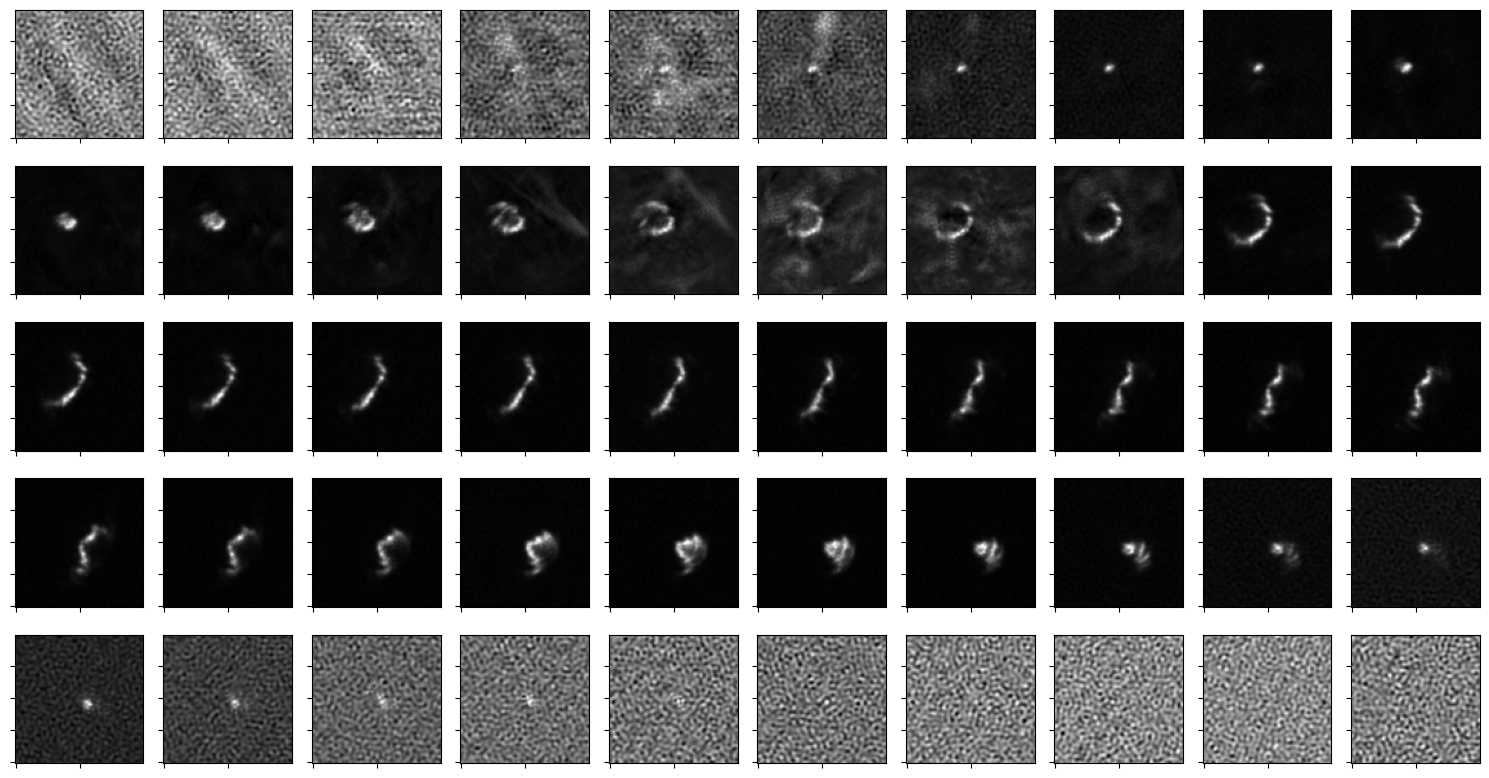

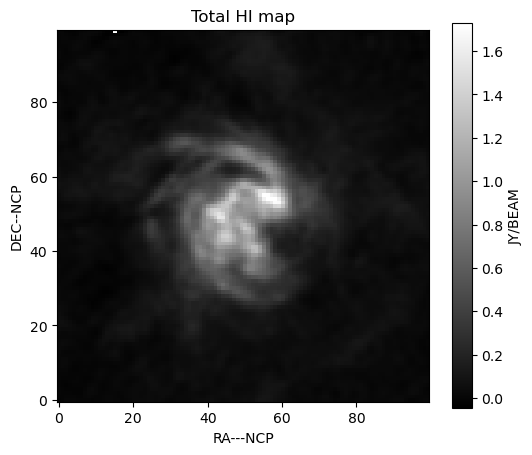

RA---NCP
DEC--NCP
VELO-HEL


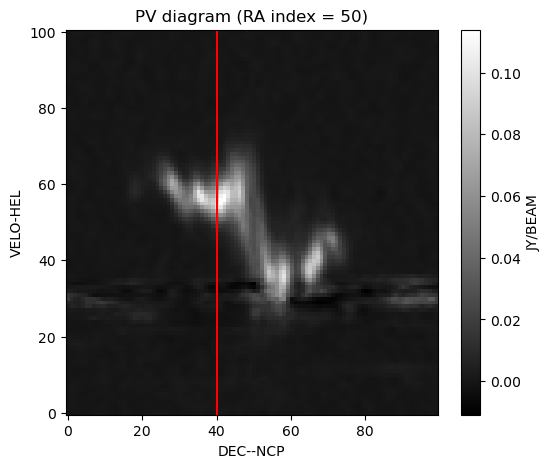

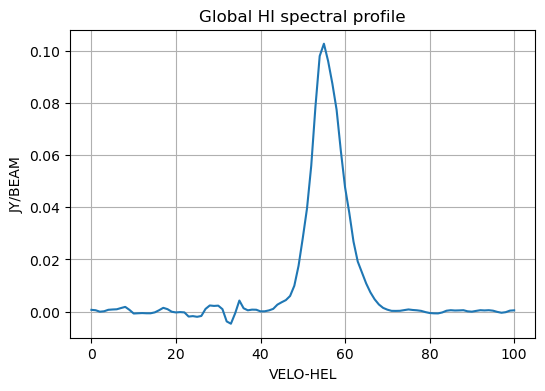

This final profile is the vertical slice at dec = 40 on the PV diagram, so thats exactly on the red vertical line in the plot of the PV diagram.


In [2]:
#Correction: The PV maps orientation was fixed by removing the transposing from the plotting steps, I printed step 7
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Load data
hdulist = fits.open('~/PROGNUM-repo/TASK6/Extra files/ngc6946.fits')
hdr = hdulist[0].header
data = hdulist[0].data

# Create a figure of 5 by 10 subplots and specify the range for each plot
fig, axes = plt.subplots(5, 10, figsize=(15, 8)) #axes is now a 2d array containing the subplots
z_indices = list(range(1, 101, 2)) # Total of 50 (corresponds to a 5x10 grid)

# Make a 5 by 10 mosaic using range(1, 101, 2)
for ax, z in zip(axes.flat, z_indices): # go through each item in a new zip containing the flattened of the axes of the subplots and the indices with the range as described before
    ax.imshow(data[z], origin='lower', cmap='gray')
    ax.set_xticklabels([]) # Remove the axis-labels as said in question
    ax.set_yticklabels([])

plt.tight_layout() # Used to prevent overlapping of the plots
plt.show()

# Total HI map using the sum of multiple maps (using numpy)
total_HI = np.sum(data[20:70], axis=0) # below 20, and above 70, there is a lot of noise visible which is why those maps are excluded

# Plot the total HI that was calculated before
plt.figure(figsize=(6,5))
im = plt.imshow(total_HI, origin='lower', cmap='gray')

# Label the headers using CTYPE1 and 2 from the hdr 
plt.xlabel(hdr['CTYPE1'])
plt.ylabel(hdr['CTYPE2'])

# plot a colourbar with the unit from the hdr as a label
cbar = plt.colorbar(im)
cbar.set_label(hdr['BUNIT'])

# Give the plot a title and use show() to ensure its always shown
plt.title("Total HI map")
plt.show()

#check header names to make sure data is in correct locations
print(hdr['CTYPE1']) # RA
print(hdr['CTYPE2']) # DEC
print(hdr['CTYPE3']) # VELO

#make Position velocity map with fixed RA at 50
pv_map = data[:, :, 50] 

# Make the figure and plot the pvmap data
plt.figure(figsize=(6,5))
im = plt.imshow(pv_map, origin='lower', aspect='auto', cmap='gray')

plt.axvline(x=40, color='red') # Vertical line at x-40

#label the x and y axis accordingly (ctype1 was RA, and 2 and 3 are declination and velocity)
plt.xlabel(hdr['CTYPE2'])
plt.ylabel(hdr['CTYPE3'])

# Add a colorbar with unit as label
cbar = plt.colorbar(im)
cbar.set_label(hdr['BUNIT'])

# Give the plot a title and use show() to ensure its always shown
plt.title("PV diagram (RA index = 50)")
plt.show()


# create the profile for the global HI spectral profile (fixed RA and Dec at 40 and 50)
profile = data[:, 40, 50]

# Make the figure and plot the profile
plt.figure(figsize=(6,4))
plt.plot(profile)

# Label with headers from file
plt.xlabel(hdr['CTYPE3'])
plt.ylabel(hdr['BUNIT'])

# Give title, add a grid and show the plot
plt.title("Global HI spectral profile")
plt.grid()
plt.show()

# Close file
hdulist.close()

# Step 7:
print('This final profile is the vertical slice at dec = 40 on the PV diagram, so thats exactly on the red vertical line in the plot of the PV diagram.')

In [ ]:
# Leave unaltered
totalpoints += 7
currentpoints += 0.0

### Galaxy Colour (5 pt) <font color='red'><b>COURSEWORK</b></font>
   
Download [SDSS_DR17_galaxies.fits](https://brightspace.rug.nl/content/enforced/457626-WBAS018-05.2025-2026.1/SDSS_DR17_galaxies.fits), which contains apparent magnitude in ``u, g, r, i, z`` five SDSS broad-band filters.

* Create a Pandas DataFrame from the FITS table.
* Filter out any data with negative values.
* Calculate every combination of colours from each broad band filter, e.g. u-g, u-r, u-i, u-z, g-r, ......
* Calculate the mean and standard deviation of the each colour.
* Use Object-Oriented Plotting to create a corner plot using derived colours.
* Set the xlim and ylim to be within three standard deviation.
* Add title for each histogram with information of the mean and standard deviation of each colour in the format of $\mu\pm\sigma$
 (to one decimal place).

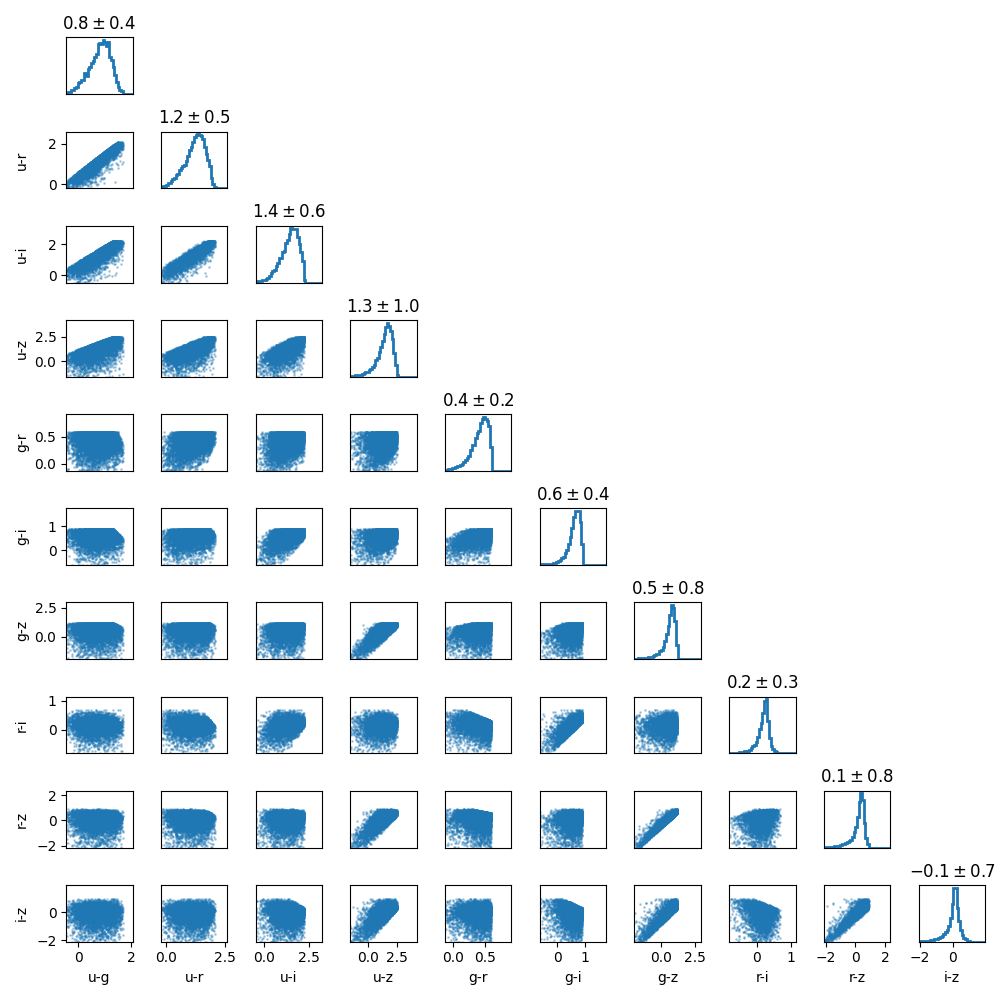
   
**Plot and answer**:

Index(['ObjID', 'u', 'g', 'r', 'i', 'z'], dtype='object')


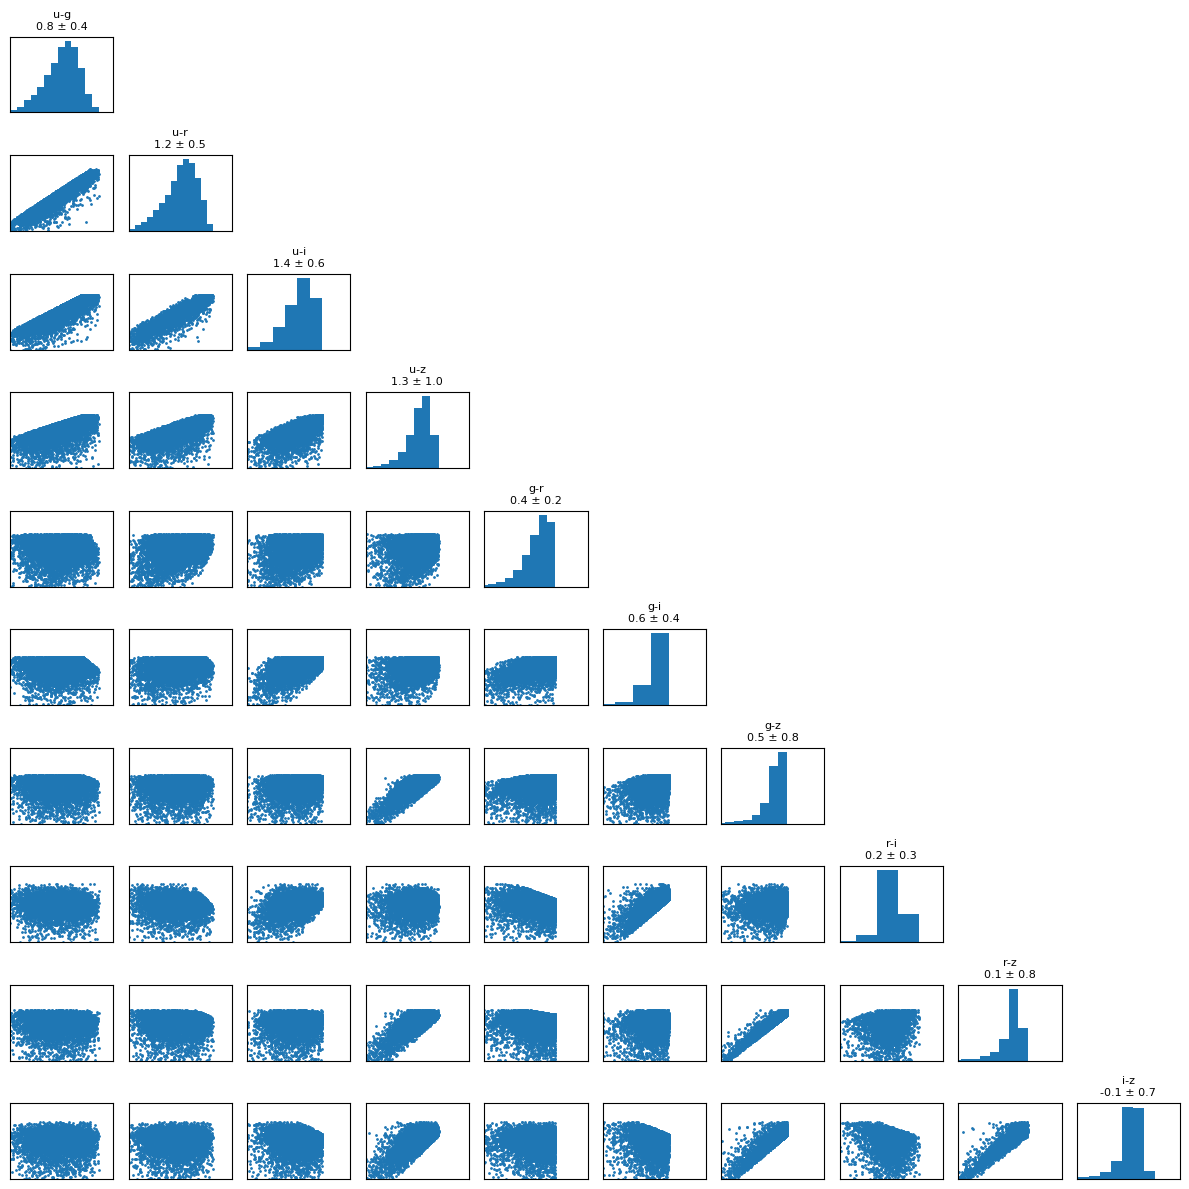

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
from astropy.table import Table

# Load/read FITS table (and convert to pandas dataframe)
df = Table.read('~/PROGNUM-repo/TASK6/Extra files/SDSS_DR17_galaxies.fits').to_pandas()

# Check column names
print(df.columns)

# Select magnitude columns (using column names found using the print)
df = df[['u', 'g', 'r', 'i', 'z']]

# Remove negative values from table
df = df[(df > 0).all(axis=1)] # Condition is true if all items in row are positive

# define the filters so we can calculate with them
filters = ['u', 'g', 'r', 'i', 'z']
colourindex = {} #empty dictionary

for f1, f2 in itertools.combinations(filters, 2): # Get all combinations of 2 items from the list filters ( itertools.combinations(list,amount of items) )
    colourindex[f"{f1}-{f2}"] = df[f1] - df[f2] # calculate each colour index for the pairs from the list filters and add it to the dictionary

# Turn the dictionary into a pandas dataframe for easier further calculations
colourindex_df = pd.DataFrame(colourindex)

# calculate mean and standard deviation for each colour index
mean = colourindex_df.mean()
sd = colourindex_df.std()


# Make a corner plot of the color indices
n = len(colourindex_df.columns) #calculate the amount of combinations of filters
fig, axes = plt.subplots(n, n, figsize=(12, 12)) # make an n by n subplot where n is the amount of filter combinations

#Define the collumns
cols = colourindex_df.columns

for i in range(n):
    for j in range(n):
        ax = axes[i, j]

        if i == j: # For the diagonal make a histogram containing the mean and standard deviation of each colour
            ax.hist(colourindex_df[cols[i]], bins=30)

            mu = mean[cols[i]]
            sigma = sd[cols[i]]

            ax.set_title(f"{cols[i]}\n{mu:.1f} ± {sigma:.1f}", fontsize=8)
            ax.set_xlim(mu - 3*sigma, mu + 3*sigma)

        elif i > j: # corner plot with the color
            ax.scatter(colourindex_df[cols[j]], colourindex_df[cols[i]], s=1)

            mu_x, sigma_x = mean[cols[j]], sd[cols[j]]
            mu_y, sigma_y = mean[cols[i]], sd[cols[i]]

            ax.set_xlim(mu_x - 3*sigma_x, mu_x + 3*sigma_x)
            ax.set_ylim(mu_y - 3*sigma_y, mu_y + 3*sigma_y)
        else:
            ax.axis('off')  # Does not show the upper triangle.

        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()


In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Astroquery: retrieving SDSS image and spectra (5 pt) <font color='red'><b>COURSEWORK</b></font>

Spiral galaxy M77 (NGC 1068) is a bright galaxy known for hosting an active galactic nucleus (AGN). With Astropy package, we construct M77's coordinate using the code below.

```python
from astropy import coordinates as coords

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")
```

* Use ``astroquery`` ([search regions](https://astroquery.readthedocs.io/en/latest/sdss/sdss.html#searching-regions-and-multiple-objects)) on the ``pos``, containing RA and DEC of this galaxy, to retrieve its SDSS spectrum using ``get_spectra()``. The search radius sets as ``10 arcsec`` for searching.
* The return object of ``get_spectra()`` is a list of [HDUList](https://docs.astropy.org/en/stable/io/fits/api/hdulists.html#astropy.io.fits.HDUList) objects.
* Retrieve flux and wavelengths using columns ``flux`` and ``loglam``. Note that the wavelength is in logarithmic value, you need to convert it back to a linear scale.
* The redshift of M77 is approximately ``z~0.0038``. Calculating the rest-frame wavelengths.
* Use Object-Oriented Plotting to plot:
    * a rest-frame spectrum which corrects the redshift effect (top)
    * a zoom-in spectrum at wavelength between 6450 and 6650 angstrom (bottom)
* Draw vertical lines for H$\alpha$ lines in both frames. Label them and show with legend.
* Draw vertical lines indicating approximately where the peak of the flux is, which in fact should be the H$\alpha$ line.
* An example plot is shown below.
* Calculating the velocity indicated by the difference between the two wavelengths.
* Share your thought using a markdown on what might be causing this offset. This question will not be graded, and meant to train a bit your scientific thinking. Feel free to express any thought.

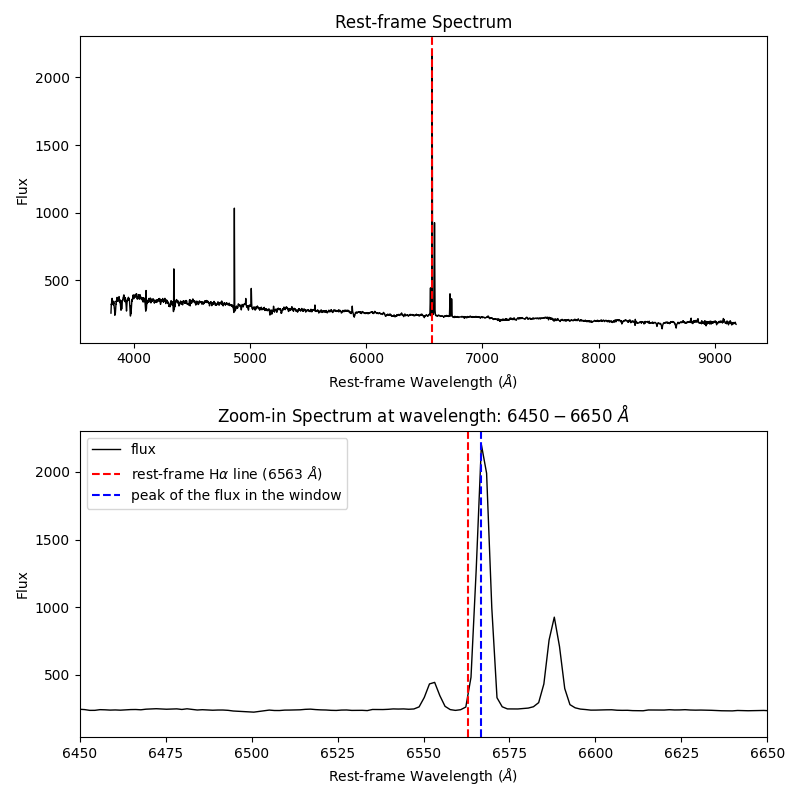

In [22]:
%pip install astroquery

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


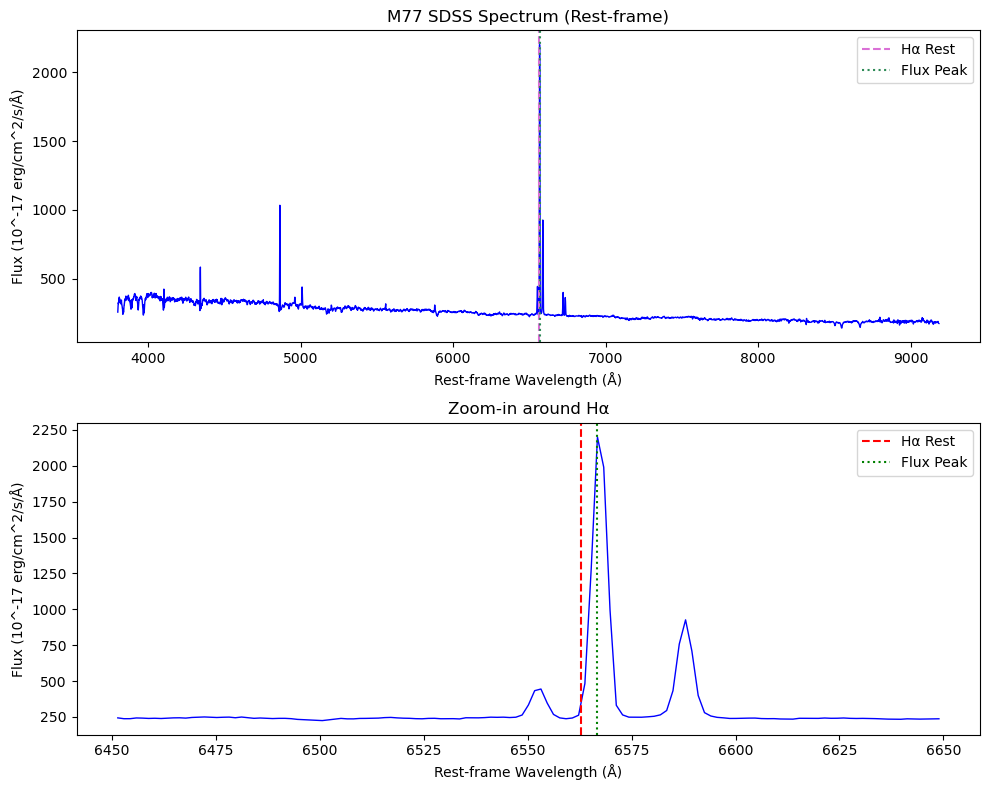

Approximate velocity shift from Hα: 182.18 km/s


In [6]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from astropy import coordinates as coords
from astroquery.sdss import SDSS
from astropy import units as u

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")

# SDSS spectrum (search radius give as 10 arcsec like in question)
xid = SDSS.query_region(pos, radius='10 arcsec', spectro=True)
spec_list = SDSS.get_spectra(matches=xid)

# Extract flux and wavelength
spec_hdul = spec_list[0]
flux = spec_hdul[1].data['flux']           # flux in 1e-17 erg/cm^2/s/A
loglam = spec_hdul[1].data['loglam']       # wavelenght log scale
wavelength = 10**loglam                     # convert to linear scale

# Correct for redshift (z ~ 0.0038)
z = 0.0038
wavelength_rest = wavelength / (1 + z) # calculate wavelength at rest

# Create plot with subplots (2x1)
fig, axs = plt.subplots(2, 1, figsize=(10, 8))

# Rest frame spectrum in the first plot of the subplots figure
axs[0].plot(wavelength_rest, flux, color='blue', lw=1) # plot rest frame
axs[0].set_xlabel('Rest-frame Wavelength (Å)') # label for x axis (wavelength)
axs[0].set_ylabel('Flux (10^-17 erg/cm^2/s/Å)') # label for y-axis (flux)
axs[0].set_title('M77 SDSS Spectrum (Rest-frame)') # title of plot

# H-alpha rest wavelength
halpha_rest = 6562.8  # calculate the rest wavelength of Halpha
axs[0].axvline(halpha_rest, color='orchid', linestyle='--', label='Hα Rest') # make a dashed line at the H alpha wavelength

# find maximum (should be Halpha line approx)
peak_idx = np.argmax(flux) # take max of flux
halpha_obs = wavelength_rest[peak_idx] # get x value for the max in the flux
axs[0].axvline(halpha_obs, color='seagreen', linestyle=':', label='Flux Peak') # draw the found maximum (possibly H alpha line)
axs[0].legend() # add a legend so labels are seen

# Zoom at H alpha area for bottom plot
mask = (wavelength_rest > 6450) & (wavelength_rest < 6650) # make a mask for the area around the H alpha line
axs[1].plot(wavelength_rest[mask], flux[mask], color='blue', lw=1) # plot the wavelength and flux for only the masked area
axs[1].axvline(halpha_rest, color='red', linestyle='--', label='Hα Rest') # again plot the rest H alpha line
axs[1].axvline(halpha_obs, color='green', linestyle=':', label='Flux Peak') # also plot the found maximum, so observed H alpha line

# Give axis names, title and show the legend.
axs[1].set_xlabel('Rest-frame Wavelength (Å)')
axs[1].set_ylabel('Flux (10^-17 erg/cm^2/s/Å)')
axs[1].legend()
axs[1].set_title('Zoom-in around Hα')

# Avoid overlap and show plot
plt.tight_layout()
plt.show()

# Calculate velocity shift
c = 3e5  # km/s
delta_lambda = halpha_obs - halpha_rest # difference in wavelength
velocity = (delta_lambda / halpha_rest) * c # calculate shift
print(f"Approximate velocity shift from Hα: {velocity:.2f} km/s") # print shift with 2 decimals

In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Comparing an image in different color scales (stretches) (4pt) <font color='red'><b>COURSEWORK</b></font>

Given is the Blaauw observatory FITS file
[20210422_Li_.00000066.FIT](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/20210422_Li_.00000066.FIT)

Use the `imdisplay()` function from the notebook *The art of plotting an image* to make a mosaic with this image using all the different scales (stretches) available to that function. 

* Add a proper docstring to the function.
* Show the used scale in the title of the plot. (hints: tight_layout, fontsize).
* Also include the image without scaling as the first plot in the mosaic.

**Answer**:

/Software/users/modules/9/software/anaconda3/2025.06/lib/python3.13/site-packages/astropy/visualization/stretch.py:543: RuntimeWarning: overflow encountered in sinh
  np.sinh(values, out=values)
/Software/users/modules/9/software/anaconda3/2025.06/lib/python3.13/site-packages/matplotlib/colors.py:777: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


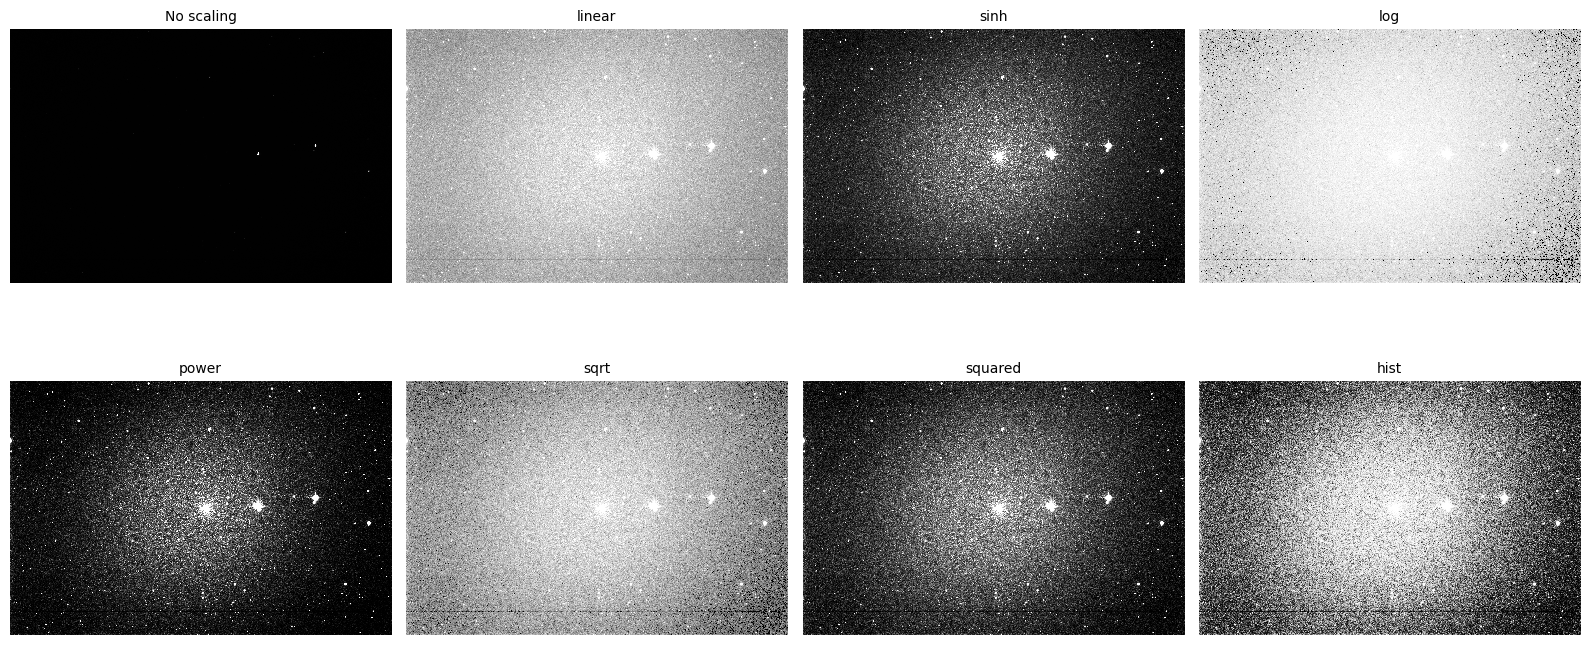

In [3]:
# Correction: Docstrings added to the notebook function

#from notebook
#---------------------------------------------------------------------------------------------------------------
from astropy.visualization import ImageNormalize
from astropy.visualization import SinhStretch, AsymmetricPercentileInterval, LinearStretch,\
                                  LogStretch, PowerStretch, SqrtStretch, SquaredStretch,\
                                  HistEqStretch, ZScaleInterval

def imdisplay(data,
              ax,
              vmin=None, vmax=None,
              percentlow=1, percenthigh=99,
              zscale=False,
              scale='linear',
              power=1.5,
              cmap='gray',
              **kwargs):
    '''convert raw FITS pixel values into an image
    by automatically choosing brightness limits
    and applying contrast transformations.
    Parameters:
    data (str) value of rfile that contains data that needs to be plotted
    ax (str/int) an axes object
    vmin vmas are maxima and minima that define the range
    percentflow and percenthigh are maxima and minima for the levels of data
    zscale (str) a stretch option
    cmap colourmap
    **kwargs any other parameters
    
    '''
    if zscale:
        '''set the interval and vmin and max'''
        # Always overwrite vmin and vmax
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(data)
    if vmin is None or vmax is None:
        ''' If either of them are none set to the value of the other'''
        interval = AsymmetricPercentileInterval(percentlow, percenthigh)
        vmin2, vmax2 = interval.get_limits(data)
        if vmin is None:
            vmin = vmin2
        if vmax is None:
            vmax = vmax2
    '''define all options for scaling'''
    if scale == 'linear':
        stretch = LinearStretch(slope=0.5, intercept=0.5)
    if scale == 'sinh':
        stretch = SinhStretch()
    if scale == 'log':
        stretch = LogStretch()
    if scale == 'power':
        stretch = PowerStretch(power)
    if scale == 'sqrt':
        stretch = SqrtStretch()
    if scale == 'squared':
        stretch = SquaredStretch()
    if scale == 'hist':
        stretch = HistEqStretch(data)  # Needs argument data and data min, max for vmin, vmax
        vmin = data.min(); vmax = data.max()

    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    return ax.imshow(data, interpolation='none', origin='lower', norm=norm, cmap=cmap, **kwargs)
#-----------------------------------------------------------------------------------------------------------------

from pathlib import Path
import numpy as np
from astropy.io import fits
from matplotlib.pyplot import subplots, show, tight_layout


#load fits file
hdulist = fits.open("~/PROGNUM-repo/TASK6/Extra files/20210422_Li_.00000066.FIT")
image_data = hdulist[0].data
if 'int' in str(image_data.dtype):
    image_data = image_data.astype('float')
hdulist.close()

# Define the scales to display as a list
scales = ['none', 'linear', 'sinh', 'log', 'power', 'sqrt', 'squared', 'hist']

# create the 'mosaic' plot 
fig, axes = subplots(2, 4, figsize=(16, 8))  # 2x4 grid (theere are 8 different scales to plot)
axes = axes.flatten() # flatten axes for further use

for ax, scale in zip(axes, scales): # for each scale from the list, get the axis and scale for the following steps
    if scale == 'none': # Display raw image without scaling
        ax.imshow(image_data, interpolation='none', origin='lower', cmap='gray')
        ax.set_title('No scaling', fontsize=10)
    else: # For every other scale in the list scales print the data using that scale (define the power as 3 if the scale used is power, otherwise use 1.5)
        imdisplay(image_data, ax, scale=scale, power=3 if scale=='power' else 1.5)
        ax.set_title(f'{scale}', fontsize=10) #use fontsize to avoid overlap
    ax.axis('off')

tight_layout() # to avoid overlap
show()

In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Image stacking optical data (6pt) <font color='red'><b>COURSEWORK</b></font>

Select one of the suitable observations from the next table or
find one yourself in the
[Blaauw Observatory Overview](https://www.astro.rug.nl/intranet/sterrenwacht/files.py)

* Following the stacking procedure in the notebook about image stacking for the data you selected. Show the result.
* Align the images and repeat the stacking procedure. Show the result.
* Remove all unnecessary code and markdown text.
* Include code and result in your report.

| nr | Folder on data server |
| :---  | :---: |
| 2  | ``/net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/`` |
| 3  | ``/net/dataserver3/data/users/sterrenwacht/images/190515/STL-6303E/i/`` |
| 4  | ``/net/dataserver3/data/users/sterrenwacht/images/190428/STL-6303E/i/`` |
| 5  | ``/net/dataserver3/data/users/sterrenwacht/images/190419/STL-6303E/i/`` |
| 6  | ``/net/dataserver3/data/users/sterrenwacht/images/180504/STL-6303E/i/`` |
| 7  | ``/net/dataserver3/data/users/sterrenwacht/images/160913/STL-6303E/i/`` |
| 8  | ``/net/dataserver3/data/users/sterrenwacht/images/140912/STL-6303E/i/`` |
| 9  | ``/net/dataserver3/data/users/sterrenwacht/images/131001/STL-6303E/i/`` |
| 10 | ``/net/dataserver3/data/users/sterrenwacht/images/101212/STL-6303E/i/`` |

**Code and plot**:

In [28]:
!pip install astroalign

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [astroalign]2 [astroalign]


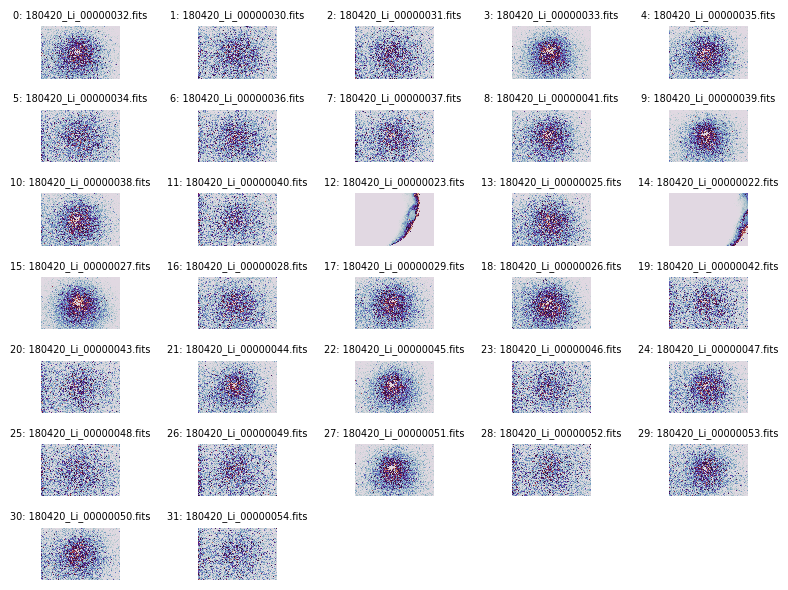

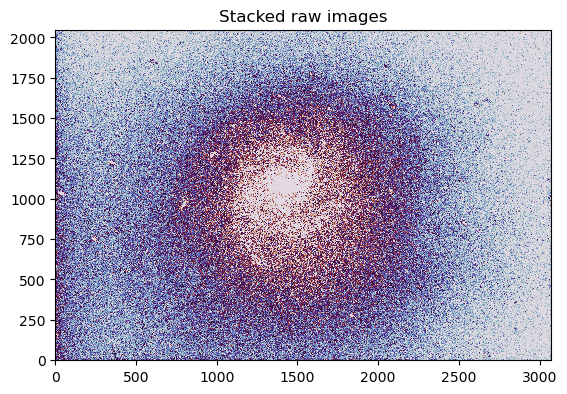

Aligning: 180420_Li_00000032.fits
Aligning: 180420_Li_00000030.fits
Aligning: 180420_Li_00000031.fits
Aligning: 180420_Li_00000033.fits
Aligning: 180420_Li_00000035.fits
Aligning: 180420_Li_00000034.fits
Aligning: 180420_Li_00000036.fits
Aligning: 180420_Li_00000037.fits
Aligning: 180420_Li_00000041.fits
Aligning: 180420_Li_00000039.fits
Aligning: 180420_Li_00000038.fits
Aligning: 180420_Li_00000040.fits
Aligning: 180420_Li_00000025.fits
Aligning: 180420_Li_00000027.fits
Aligning: 180420_Li_00000028.fits
Aligning: 180420_Li_00000029.fits
Aligning: 180420_Li_00000026.fits
Aligning: 180420_Li_00000042.fits
Aligning: 180420_Li_00000043.fits
Aligning: 180420_Li_00000044.fits
Aligning: 180420_Li_00000045.fits
Aligning: 180420_Li_00000046.fits
Aligning: 180420_Li_00000047.fits
Aligning: 180420_Li_00000048.fits
Aligning: 180420_Li_00000049.fits
Aligning: 180420_Li_00000051.fits
Aligning: 180420_Li_00000052.fits
Aligning: 180420_Li_00000053.fits
Aligning: 180420_Li_00000050.fits
Aligning: 1804

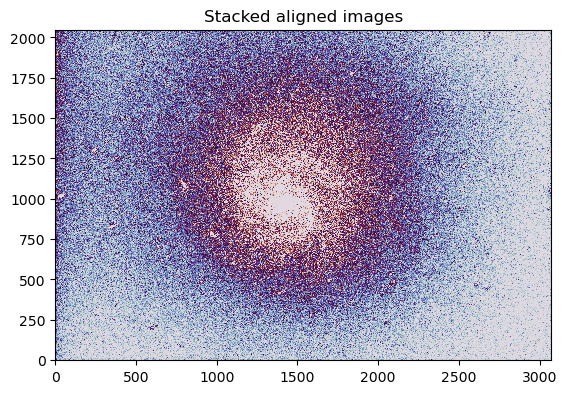

In [32]:
# Import necessary modules
from pathlib import Path
import numpy as np
from astropy.io import fits
from astropy.visualization import ImageNormalize, LinearStretch, SinhStretch, LogStretch, PowerStretch, SqrtStretch, SquaredStretch, HistEqStretch, AsymmetricPercentileInterval, ZScaleInterval
from matplotlib.pyplot import subplots, figure, show

# FROM NOTEBOOK: astroalign is used for image registration/alignment
import astroalign as aa  

# FROM NOTEBOOK: image display function
def imdisplay(data, ax, vmin=None, vmax=None, percentlow=1, percenthigh=99,
              zscale=False, scale='linear', power=1.5, cmap='gray', **kwargs):
    if zscale:
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(data)
    if vmin is None or vmax is None:
        interval = AsymmetricPercentileInterval(percentlow, percenthigh)
        vmin2, vmax2 = interval.get_limits(data)
        if vmin is None: vmin = vmin2
        if vmax is None: vmax = vmax2

    if scale == 'linear': stretch = LinearStretch(slope=0.5, intercept=0.5)
    elif scale == 'sinh': stretch = SinhStretch()
    elif scale == 'log': stretch = LogStretch()
    elif scale == 'power': stretch = PowerStretch(power)
    elif scale == 'sqrt': stretch = SqrtStretch()
    elif scale == 'squared': stretch = SquaredStretch()
    elif scale == 'hist': 
        stretch = HistEqStretch(data)
        vmin, vmax = data.min(), data.max()

    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    return ax.imshow(data, interpolation='none', origin='lower', norm=norm, cmap=cmap, **kwargs)


# FROM NOTEBOOK: make the path to the directory containing the files (using own path to image files)
datadir = "~/PROGNUM-repo/DATA/BLAAUW/"
datadir = Path(datadir).expanduser() # To make sure the ~ works

# FROM NOTEBOOK: exclude BIAS, FLAT, DARK and get relevant files of the extensions .fits, .fit, .fts
from math import ceil
excludes = ['BIAS', 'FLAT', 'DARK']
filepaths = [f for f in datadir.iterdir() if f.suffix.lower() in ['.fits', '.fit', '.fts']
             and not any(ext in f.name for ext in excludes)]

# FROM NOTEBOOK: mosaic display to remove irrelevant images
fig = figure(figsize=(8,6), tight_layout=True)
count = 1
ncols = 5
nrows = ceil(len(filepaths)/ncols)
for i, filepath in enumerate(filepaths):
    hdulist = fits.open(filepath)
    ax = fig.add_subplot(nrows, ncols, count)
    ax.axis('off')
    imdisplay(hdulist[0].data, ax, scale='power', power=3, cmap='twilight')
    ax.set_title(f"{i}: {filepath.name}", fontsize=7)
    count += 1
    hdulist.close()
show()

# FROM NOTEBOOK: exclude wrong images (from plot we can see that those are 22 and 23) and add the correct/good ones to new list
new_filepaths = [f for f in filepaths if not f.name.endswith('22.fits') and not f.name.endswith('23.fits')]
images = []
for f in new_filepaths:
    with fits.open(f) as hdulist:
        images.append(hdulist[0].data.astype('float'))

# alighning and stacking the images
# FROM NOTEBOOK
datacube = np.stack(images)
stacked_images = np.median(datacube, axis=0)

fig, ax = subplots()
imdisplay(stacked_images, ax, percentlow=5, percenthigh=95, scale='squared', cmap='twilight')
ax.set_title("Stacked raw images")
show()

# FROM NOTEBOOK
target = new_filepaths[6]  # select target image
with fits.open(target) as hdulist:
    target_im = hdulist[0].data.astype('float')

aligned_images = []
for f in new_filepaths:
    with fits.open(f) as hdulist:
        print(f"Aligning: {f.name}")
        try:
            aligned, _ = aa.register(hdulist[0].data.astype('float'), target_im,
                                     detection_sigma=5.0, max_control_points=100, min_area=5)
            aligned_images.append(aligned)
        except:
            print("Failed")

# FROM NOTEBOOK: median stacking of aligned images and vertical flip
datacube_aligned = np.stack(aligned_images)
stacked_reg_images = np.median(datacube_aligned, axis=0)

fig, ax = subplots()
imdisplay(np.flipud(stacked_reg_images), ax, percentlow=5, percenthigh=95, scale='squared', cmap='twilight')
ax.set_title("Stacked aligned images")
show()

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")